In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import glob
import ast

import scipy.stats as stats
from scipy.integrate import cumtrapz
import matplotlib.pyplot as plt

import utils

#handle warnings
import warnings
warnings.filterwarnings("ignore")
np.random.seed(3)
np.set_printoptions(precision=5)

In [2]:
#Define your datapath here
name = "CrTeNW_data"
# Define your analyzing UF_result_path here and the UFs to compare here
UF = "RF"
UF_array = ["XGBEns", "GP", "RF"]

#Define Color here/ you may redesign using the color palette
colors = ['green','orange','red']
color_mapping = dict(zip(UF_array, colors))

root_dir = str(Path(os.getcwd()))
from_dir = root_dir + "/data/"
to_dir = root_dir + "/results/"

df_cleaned, X, Y, clean_feature_list, clean_result_col = utils.load_and_clean_data(name, feature_col_num=0,target="length")

Y_global_max = np.max(Y)



Loading CrTeNW_data dataset...
Features list: ['Te', 'Size', 'Ar', 'H_2', 'R_temp', 'G_temp', 'G_time', 'Q_Pre']
Feature size: 8
Dataset size: 94
Target column: Length
Sum of target values: 733.4399999999999
Mean of target values: 7.802553191489361
Y non-zero: 45 
Y zero: 49


## For histogram

Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/RF_CrTeNW_data/Summary_PAM_RF_CrTeNW_data_2025_9_30.csv
Number of iteration :  100


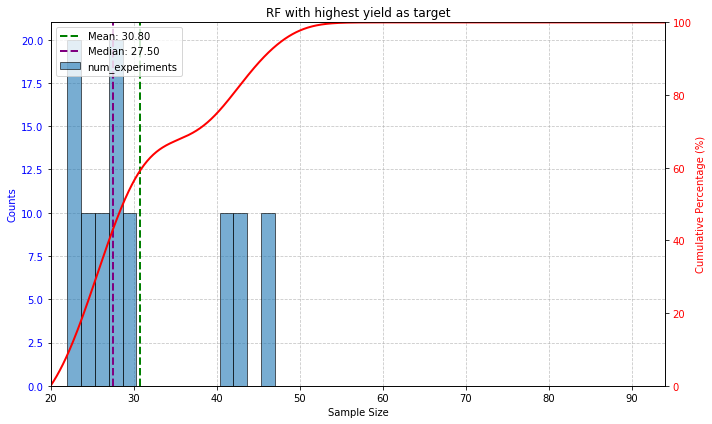

In [3]:
subfolder_path = os.path.join(to_dir, f"{UF}_{name}")
filepath_pattern = os.path.join(subfolder_path, f"Summary_PAM_{UF}_{name}*.csv")

matches = glob.glob(filepath_pattern)

if len(matches) == 0:
    raise FileNotFoundError(f"No file found matching {filepath_pattern}")
else:
    # Sort by modification time, descending, pick first
    newest_filepath = max(matches, key=os.path.getmtime)
    filepath = newest_filepath
    # Optionally print or log
    print("Using file:", filepath)

df = pd.read_csv(filepath)
data = df.iloc[:, 1]
labels = df.iloc[:, 0]

# For cross-checking the number of iteration in the summary file
print("Number of iteration : ",len(data))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the histogram on the primary axis (counts)
counts, bins, patches = ax1.hist(data, bins=15, edgecolor='black', alpha=0.6)
ax1.set_xlabel('Sample Size')
ax1.set_ylabel('Counts', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Enable unified grid
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Compute mean and median
mean_value = data.mean()
median_value = data.median()

# Mark mean and median with vertical lines on the primary axis
ax1.axvline(mean_value, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
ax1.axvline(median_value, color='purple', linestyle='--', linewidth=2, label=f'Median: {median_value:.2f}')

# Create the secondary axis for the smooth cumulative percentage curve
ax2 = ax1.twinx()

# Define a dense range of x values over the data's range
x = np.linspace(20, 94, 1000)

# Compute the KDE and cumulative percentage
kde = stats.gaussian_kde(data)
pdf = kde(x)
cdf = cumtrapz(pdf, x, initial=0)
cdf_percent = (cdf / cdf[-1]) * 100

# Plot the cumulative percentage on the secondary axis
ax2.plot(x, cdf_percent, color='red', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

# Set x-axis limits
ax1.set_xlim(20, 94)

# Combine legend entries from ax1 (which now includes mean and median markers)
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc='upper left')

plt.title(f'{UF} with highest yield as target')
plt.tight_layout()
plt.show()

Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/XGBEns_CrTeNW_data/Summary_PAM_XGBEns_CrTeNW_data_2025_9_29.csv
Variance for XGBEns: 17.41
Max Nc for XGBEns: 35


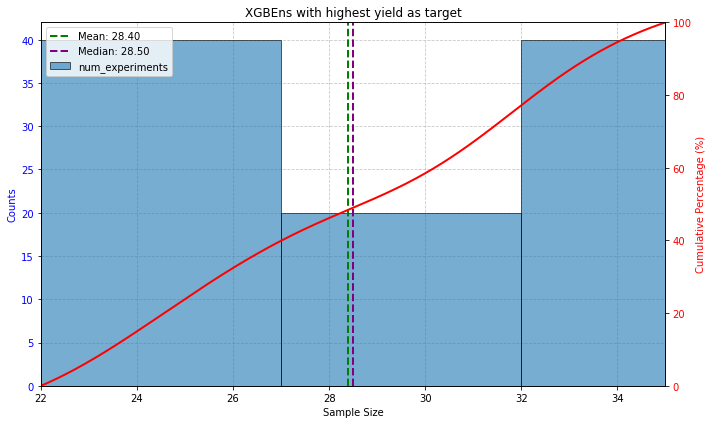

Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/GP_CrTeNW_data/Summary_PAM_GP_CrTeNW_data_2025_9_30.csv
Variance for GP: 56.98
Max Nc for GP: 50


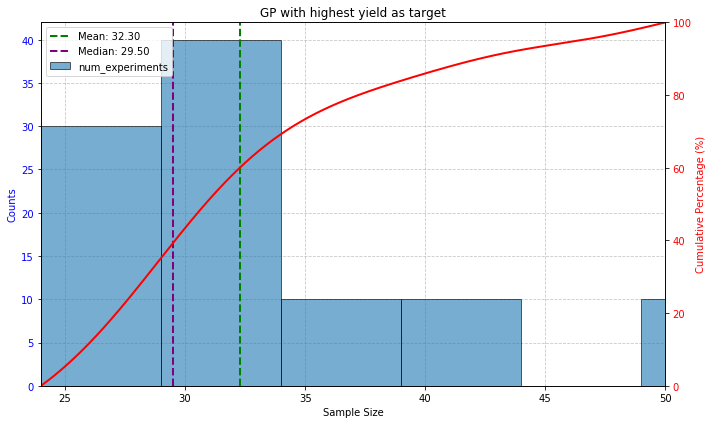

Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/RF_CrTeNW_data/Summary_PAM_RF_CrTeNW_data_2025_9_30.csv
Variance for RF: 74.91
Max Nc for RF: 47


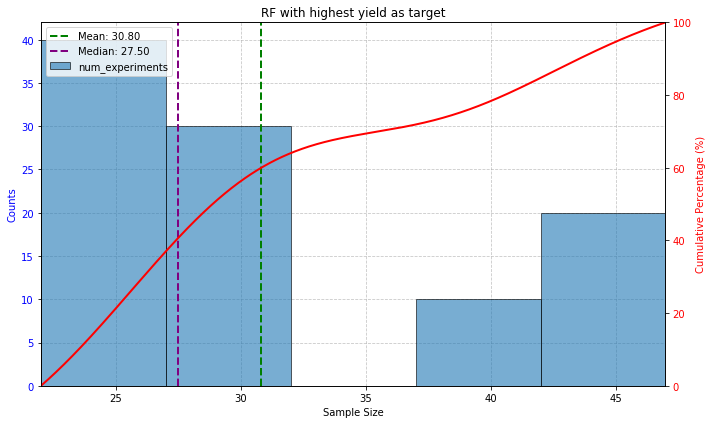

In [4]:
results = {}
to_save_plot = False  

for UF in UF_array:
    subfolder_path = os.path.join(to_dir, f"{UF}_{name}")
    filepath_pattern = os.path.join(subfolder_path, f"Summary_PAM_{UF}_{name}*.csv")

    matches = glob.glob(filepath_pattern)
    if not matches:
        raise FileNotFoundError(f"No file found matching {filepath_pattern}")
    else:
        filepath = max(matches, key=os.path.getmtime)
        print("Using file:", filepath)

    df = pd.read_csv(filepath)
    labels = df.iloc[:, 0]
    data   = df.iloc[:, 1]

    variance_value = data.var(ddof=1)
    max_nc = data.max()

    results[UF] = {
        "data": data,
        "labels": labels,
        "variance": variance_value,
        "max_nc": max_nc
    }

    print(f"Variance for {UF}: {variance_value:.2f}")
    print(f"Max Nc for {UF}: {max_nc}")

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10,6))
    bin_width = 5
    # adjust range or compute from data
    min_x = np.floor(data.min())
    max_x = np.ceil(data.max())
    bins = np.arange(min_x, max_x + bin_width, bin_width)

    counts, bins_used, patches = ax1.hist(data, bins=bins, edgecolor='black', alpha=0.6)
    ax1.set_xlabel('Sample Size')
    ax1.set_ylabel('Counts', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_axisbelow(True)

    mean_value = data.mean()
    median_value = data.median()
    ax1.axvline(mean_value, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
    ax1.axvline(median_value, color='purple', linestyle='--', linewidth=2, label=f'Median: {median_value:.2f}')

    ax2 = ax1.twinx()
    x = np.linspace(min_x, max_x, 1000)
    kde = stats.gaussian_kde(data.values)
    pdf = kde(x)
    cdf = cumtrapz(pdf, x, initial=0)
    cdf_percent = (cdf / cdf[-1]) * 100
    ax2.plot(x, cdf_percent, color='red', linewidth=2)
    ax2.set_ylabel('Cumulative Percentage (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 100)

    ax1.set_xlim(min_x, max_x)

    lines, labels_legend = ax1.get_legend_handles_labels()
    ax1.legend(lines, labels_legend, loc='upper left')
    plt.title(f'{UF} with highest yield as target')
    plt.tight_layout()

    if to_save_plot:
        plot_filename = f"{UF}_histogram.png"
        save_filepath = os.path.join(to_dir, plot_filename)
        plt.savefig(save_filepath, dpi=300, bbox_inches='tight')

    plt.show()


[XGBEns] Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/XGBEns_CrTeNW_data/Summary_PAM_XGBEns_CrTeNW_data_2025_9_29.csv
[GP] Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/GP_CrTeNW_data/Summary_PAM_GP_CrTeNW_data_2025_9_30.csv
[RF] Using file: /home/common2/snap/snapd-desktop-integration/ABSI/results/RF_CrTeNW_data/Summary_PAM_RF_CrTeNW_data_2025_9_30.csv


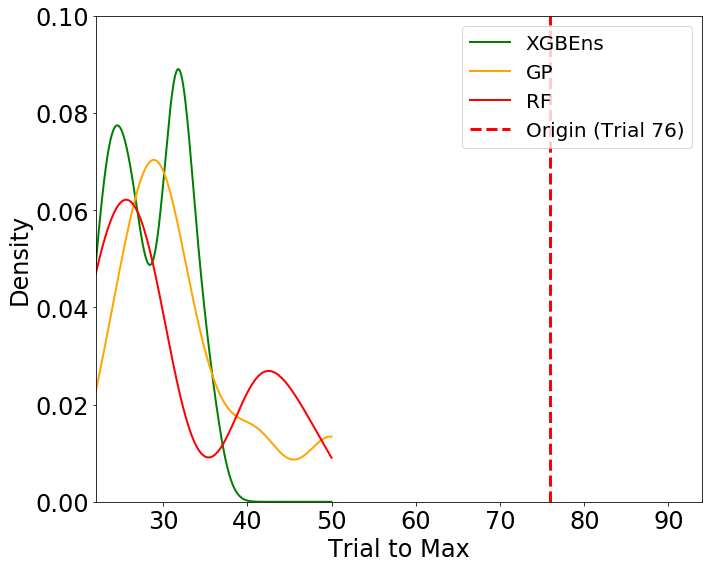

In [10]:
# 1) load newest summary per UF
data_dict = {}
for UF in UF_array:
    subfolder_path   = os.path.join(to_dir, f"{UF}_{name}")
    filepath_pattern = os.path.join(subfolder_path, f"Summary_PAM_{UF}_{name}*.csv")
    matches = glob.glob(filepath_pattern)
    if not matches:
        raise FileNotFoundError(f"No file found matching pattern {filepath_pattern}")

    newest_filepath = max(matches, key=os.path.getmtime)
    print(f"[{UF}] Using file: {newest_filepath}")

    df = pd.read_csv(newest_filepath)
    # take first two columns (positionally)
    labels = df.iloc[:, 0]
    data   = df.iloc[:, 1].astype(float)

    data_dict[UF] = {"labels": labels, "data": data}

# 2) compute global plotting grid (guard equal min/max)
vals = [v["data"] for v in data_dict.values()]
global_min = min(s.min() for s in vals)
global_max = max(s.max() for s in vals)
if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise ValueError("Non-finite data encountered.")

if np.isclose(global_min, global_max):
    # widen a hair to avoid zero-length grid
    half = 1e-9
    global_min -= half
    global_max += half

x = np.linspace(global_min, global_max, 1000)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

for UF in UF_array:
    s = data_dict[UF]["data"]
    if s.size < 2 or s.nunique(dropna=True) < 2:
        print(f"[{UF}] Not enough variation for KDE; skipping.")
        continue

    kde = stats.gaussian_kde(s.values)
    pdf = kde(x)
    ax.plot(x, pdf,
            linewidth=2,
            label=UF,   # ← set the label for this UF
            color=color_mapping[UF]
           )

# add the vertical line too, without overriding legend
ax.axvline(x=76,
           color='red',
           linestyle='--',
           linewidth=3,
           label='Origin (Trial 76)'
          )

# then at the end add legend
ax.set_xlim(22, 94)
ax.set_ylim(0.00,0.10)
ax.tick_params(axis="both", labelsize=24)
ax.set_xlabel('Trial to Max', fontsize=24)
ax.set_ylabel('Density', fontsize=24)

ax.legend(loc='upper right', fontsize=20)
plt.tight_layout()
plt.show()

In [11]:
# Collect each file from the subfolder
folder_dfs = {}

for UF in UF_array:
    subdir = to_dir + f"/{UF}_{name}"
    file_pattern = os.path.join(subdir, f"PAM_{UF}_{name}_*.csv")


    files = sorted(glob.glob(file_pattern))
    
    if not files:
        print(f"No files found for UF {UF} with pattern {file_pattern}")
        continue

    list_dfs = []
    for file in files:
        try:
            df_file = pd.read_csv(file, header=0)
            list_dfs.append(df_file)
        except Exception as e:
            print(f"Warning: failed to read {file}: {e}")

    if list_dfs:
        df_combined = pd.concat(list_dfs, ignore_index=True, sort=False)
        folder_dfs[UF] = df_combined
    else:
        print(f"No valid CSVs read for UF {UF} with pattern {file_pattern}")

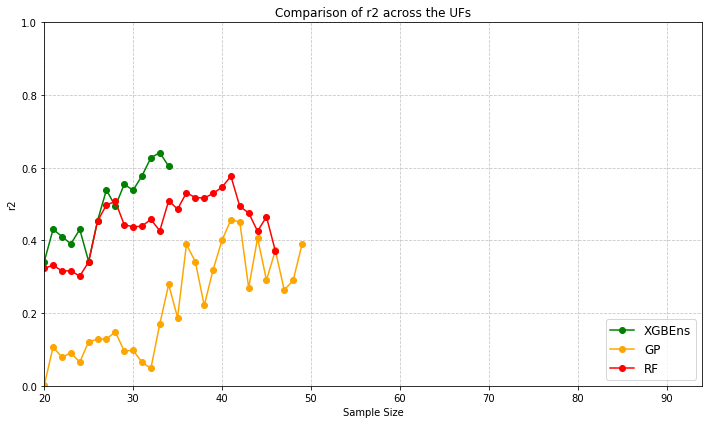

In [12]:
# Plotting the target variable "acq_value" from each DataFrame
targety1 = "r2"
plt.figure(figsize=(10, 6))
plt.xlim(20, 94)
plt.ylim(0,1)

def convert_y_true(val):
    # If the value is a string with brackets, remove them and convert to float.
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        return float(val.strip("[]"))
    return val

for i, UF in enumerate(UF_array):
    if UF in folder_dfs:
        df = folder_dfs[UF]
        # Group by sample_size to compute mean and std for the target
        stats = df.groupby("sample_size")[targety1].agg(["mean", "std"]).reset_index()
        plt.errorbar(stats["sample_size"], stats["mean"],
                     #yerr=stats["std"], 
                     fmt='-o', 
                     capsize=5,
                     label=f'{UF}',
                     color=color_mapping[UF])
    else:
        print(f"Data for {UF} is missing.")

plt.xlabel("Sample Size")
plt.ylabel(f"{targety1}")
plt.title(f"Comparison of {targety1} across the UFs")
plt.legend(loc=4, fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

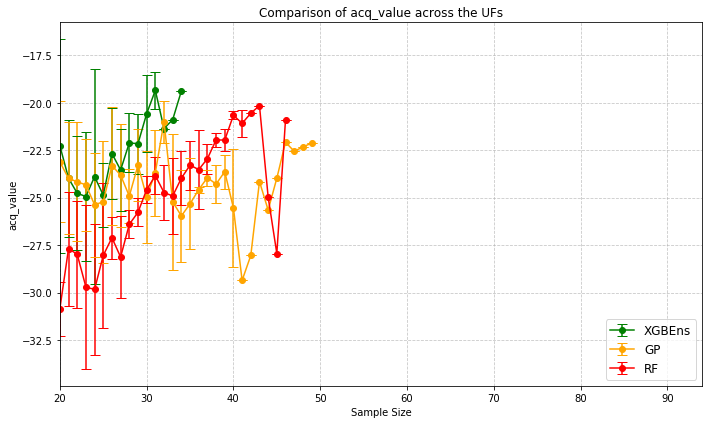

In [13]:
import os, pandas as pd, matplotlib.pyplot as plt

targety1 = "acq_value"

# --- 0) Build folder_dfs if it doesn't exist ---
try:
    folder_dfs  # noqa: F401
except NameError:
    if 'files' in globals() and 'UF_array' in globals():
        if len(files) < len(UF_array):
            raise RuntimeError("Not enough files to map to UF_array. Define 'folder_dfs' explicitly.")
        folder_dfs = {UF: pd.read_csv(f) for UF, f in zip(UF_array, files)}
    else:
        raise RuntimeError("Define 'folder_dfs' OR provide both 'files' and 'UF_array'.")

# --- 1) Ensure color_mapping exists ---
if 'color_mapping' not in globals():
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9'])
    color_mapping = {UF: colors[i % len(colors)] for i, UF in enumerate(UF_array)}

# --- 2) Plot (with your numeric coercion + named aggregation) ---
plt.figure(figsize=(10, 6))
plt.xlim(20, 94)

for UF in UF_array:
    if UF not in folder_dfs:
        print(f"Data for {UF} is missing.")
        continue

    df = folder_dfs[UF].copy()

    # robust numeric coercion
    df["sample_size"] = pd.to_numeric(df["sample_size"], errors="coerce")
    s = (df[targety1].astype(str).str.strip().str.strip("[]").str.replace(",", "", regex=False))
    df[targety1] = pd.to_numeric(s, errors="coerce")
    df = df.dropna(subset=["sample_size", targety1])

    # group & summarize (named aggregation)
    stats = (df.groupby("sample_size", as_index=False)
               .agg(mean=(targety1, "mean"),
                    std =(targety1, "std"))
               .sort_values("sample_size"))
    stats["std"] = stats["std"].fillna(0)

    plt.errorbar(stats["sample_size"], stats["mean"],
                 yerr=stats["std"], fmt='-o', capsize=5,
                 color=color_mapping[UF], label=f"{UF}")

plt.xlabel("Sample Size")
plt.ylabel(targety1)
plt.title(f"Comparison of {targety1} across the UFs")
plt.legend(loc=4, fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## Cummulative Regret

In [14]:
# Collect each file from the subfolder
folder_dfs = {}

for UF in UF_array:
    subdir = to_dir + f"/{UF}_{name}"
    file_pattern = os.path.join(subdir, f"PAM_{UF}_{name}_*.csv")
    files = sorted(glob.glob(file_pattern))
    
    if not files:
        print(f"No files found for UF {UF} with pattern {file_pattern}")
        continue

    list_dfs = []
    for file in files:
        try:
            df_file = pd.read_csv(file, header=0)
            list_dfs.append(df_file)
        except Exception as e:
            print(f"Warning: failed to read {file}: {e}")

    if list_dfs:
        df_combined = pd.concat(list_dfs, ignore_index=True, sort=False)
        folder_dfs[UF] = df_combined
    else:
        print(f"No valid CSVs read for UF {UF} with pattern {file_pattern}")


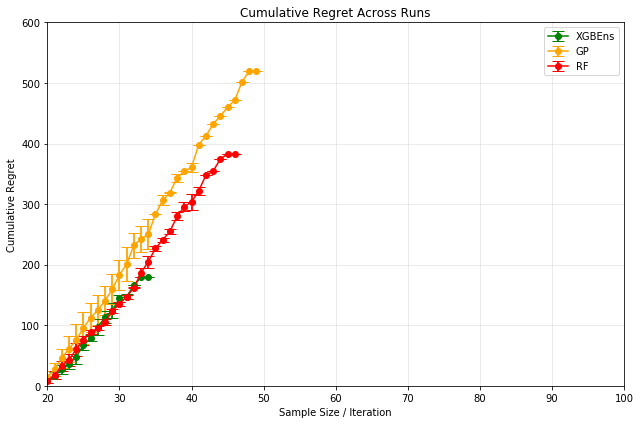

In [16]:
import os, glob, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def y_to_scalar(v):
    # robust parse from string/list to scalar; use max for batch>1
    if isinstance(v, str):
        try:
            v = ast.literal_eval(v)
        except Exception:
            v = v.strip("[]()")
            parts = [p for p in v.replace(",", " ").split() if p]
            return float(parts[0]) if parts else np.nan
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        a = np.asarray(v, dtype=float).ravel()
        return float(np.max(a))
    try:
        return float(v)
    except Exception:
        return np.nan

plt.figure(figsize=(9, 6))
ax = plt.gca()

for UF in UF_array:
    subdir = os.path.join(to_dir, f"{UF}_{name}")
    file_pattern = os.path.join(subdir, f"PAM_{UF}_{name}_*.csv")
    files = sorted(glob.glob(file_pattern))
    if not files:
        print(f"[{UF}] no files for pattern: {file_pattern}")
        continue

    runs = []
    for run_id, fp in enumerate(files):
        df = pd.read_csv(fp, header=0)

        # parse/clean
        ssz = pd.to_numeric(df['sample_size'], errors='coerce')
        ytr = df['y_true'].apply(y_to_scalar)

        run = pd.DataFrame({'run_id': run_id,
                            'sample_size': ssz,
                            'y_true_scalar': ytr}).dropna()

        # If a file contains repeated sample_size rows (or you accidentally concatenated snapshots),
        # keep the last value per sample_size within THIS run.
        run = (run.sort_values('sample_size')
                    .drop_duplicates(subset=['sample_size'], keep='last'))

        run['regret'] = float(Y_global_max) - run['y_true_scalar']
        # per-run cumulative regret
        run['cumulative_regret'] = run.groupby('run_id')['regret'].cumsum()

        runs.append(run[['run_id', 'sample_size', 'cumulative_regret']])

    all_df = pd.concat(runs, ignore_index=True)

    # Aggregate across runs at each iteration
    agg = (all_df.groupby('sample_size')['cumulative_regret']
                 .agg(['mean', 'std', 'count'])   # sample std (ddof=1)
                 .reset_index()
                 .rename(columns={'count': 'n'}))

    # diagnostics: count on iteration
    #print(f"[{UF}] runs per sample_size (first 10):")
    #print(agg[['sample_size','n']].head(10))

    # only draw bars where we have at least 2 runs (std is NaN for n=1 with ddof=1)
    yerr = agg['std'].where(agg['n'] >= 2, np.nan)

    plt.errorbar(agg['sample_size'], agg['mean'],
                 yerr=yerr, fmt='-o', capsize=6,
                 elinewidth=1.8, ecolor=color_mapping[UF],color=color_mapping[UF], label=UF)

# cosmetics
ax.set_xlim(20, 100)
ax.set_ylim(0, 600)
plt.xlabel("Sample Size / Iteration")
plt.ylabel("Cumulative Regret")
plt.title("Cumulative Regret Across Runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


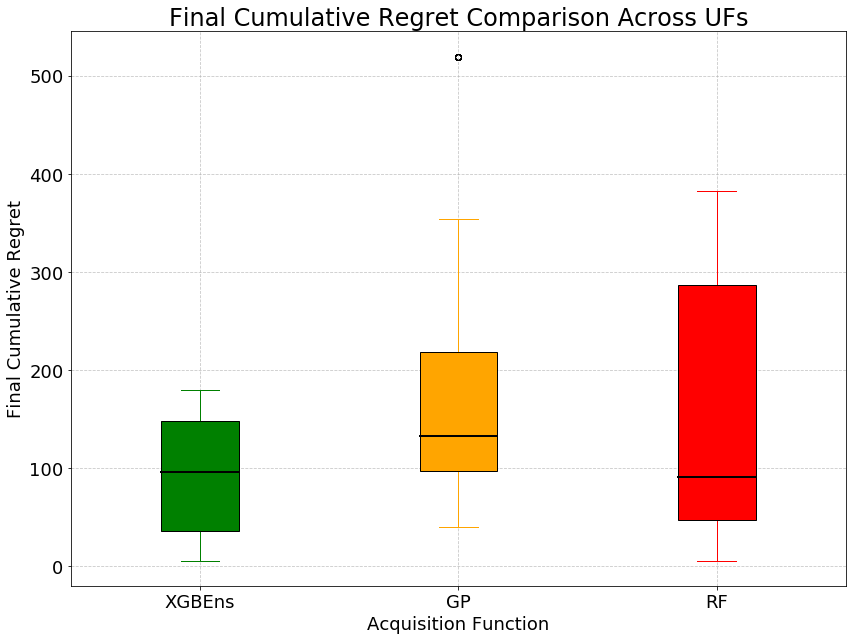

In [21]:
def convert_y_true(val):
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
        except Exception:
            s = val.strip("[]()")
            parts = [p for p in s.replace(",", " ").split() if p]
            return float(parts[0]) if parts else np.nan
        # if list/tuple, take max as the observed (batch) outcome
        if isinstance(parsed, (list, tuple)):
            a = np.asarray(parsed, dtype=float).ravel()
            return float(np.nanmax(a)) if a.size else np.nan
        try:
            return float(parsed)
        except Exception:
            return np.nan
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        a = np.asarray(val, dtype=float).ravel()
        return float(np.nanmax(a)) if a.size else np.nan
    try:
        return float(val)
    except Exception:
        return np.nan

final_regrets = {}  # UF -> list of final cumulative regrets (one per run/file)

for UF in UF_array:
    subdir = os.path.join(to_dir, f"{UF}_{name}")
    files = sorted(glob.glob(os.path.join(subdir, f"PAM_{UF}_{name}_*.csv")))
    if not files:
        print(f"[{UF}] no files found in {subdir}")
        continue

    values = []
    for fp in files:
        df = pd.read_csv(fp, header=0)

        # parse and clean
        df = df.copy()
        df['sample_size'] = pd.to_numeric(df['sample_size'], errors='coerce')
        df['y_true'] = df['y_true'].apply(convert_y_true)
        df = df.dropna(subset=['sample_size', 'y_true']).sort_values('sample_size')

        # if this file is an incremental snapshot of the same run, keep the last row per sample_size
        df = df.drop_duplicates(subset=['sample_size'], keep='last')

        # instantaneous & cumulative regret for THIS run
        df['regret'] = float(Y_global_max) - df['y_true']
        df['cumulative_regret'] = df['regret'].cumsum()  # cumulative over iterations

        # final (last iteration) cumulative regret for this run
        values.append(float(df['cumulative_regret'].iloc[-1]))

    final_regrets[UF] = values

# ---------------- boxplot (color per UF) ----------------
plt.figure(figsize=(12, 9))
bp = plt.boxplot([final_regrets[UF] for UF in UF_array],
                 labels=UF_array, patch_artist=True)

# color each box by UF
for patch, UF in zip(bp['boxes'], UF_array):
    patch.set_facecolor(color_mapping.get(UF, 'lightgray'))

# thicker, visible medians
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)

# (optional) color whiskers / caps to match the box color
for (w1, w2), UF in zip(zip(bp['whiskers'][0::2], bp['whiskers'][1::2]), UF_array):
    c = color_mapping.get(UF, 'gray')
    w1.set_color(c); w2.set_color(c)
for (c1, c2), UF in zip(zip(bp['caps'][0::2], bp['caps'][1::2]), UF_array):
    c = color_mapping.get(UF, 'gray')
    c1.set_color(c); c2.set_color(c)

plt.xlabel("Acquisition Function", fontsize=18)
plt.ylabel("Final Cumulative Regret",fontsize=18)
plt.title("Final Cumulative Regret Comparison Across UFs",fontsize=24)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()
